In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv("/content/IMDB Dataset.csv.zip")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data['review'], data['sentiment'], test_size=0.2, random_state=42
)

In [ ]:
tokenizer = Tokenizer(num_words=15000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout

model = Sequential()

model.add(Embedding(15000, 128, input_length=200))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(32))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 214s 335ms/step - accuracy: 0.8230 - loss: 0.3975 - val_accuracy: 0.8818 - val_loss: 0.2927
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 267s 344ms/step - accuracy: 0.9109 - loss: 0.2355 - val_accuracy: 0.8930 - val_loss: 0.2602
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 326ms/step - accuracy: 0.9398 - loss: 0.1647 - val_accuracy: 0.8940 - val_loss: 0.2682
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.9564 - loss: 0.1254 - val_accuracy: 0.8920 - val_loss: 0.3124
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 205s 329ms/step - accuracy: 0.9719 - loss: 0.0857 - val_accuracy: 0.8826 - val_loss: 0.3869
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 328ms/step - accuracy: 0.9809 - loss: 0.0641 - val_accuracy: 0.8770 - val_loss: 0.4052
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 218s 349ms/step - accuracy: 0.9824 - loss: 0.0578 - val_accuracy: 0.8767 - val_loss: 0.4125
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 213s 341ms/step - accuracy: 0.9876 -

In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8678 - loss: 0.6198
Test Accuracy: 0.8677999973297119


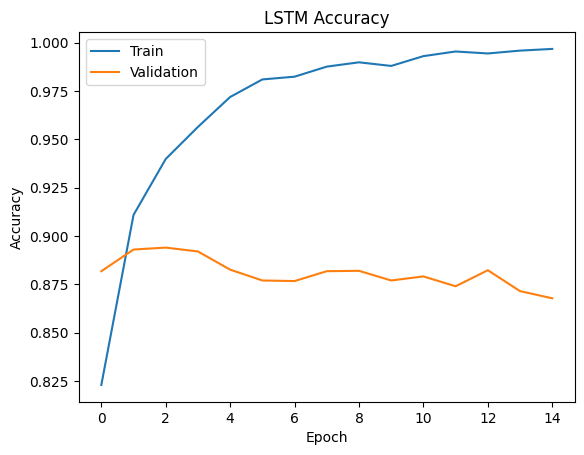

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
sample = ["This movie was not good"]

seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=200)

prediction = model.predict(pad)

print("Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive 😊")
else:
    print("Negative 😠")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
Score: 0.03809721
Negative 😠
